# Perfil sociodemográfico de la paternidad: clasificación con regresión logística y regularización
### Portafolio de Ciencia de Datos · Proyecto 2 · Implementación en Python
**Ricardo José Córdova Soriano** · Septiembre 2026

## Objetivo y enfoque

Este proyecto construye un **modelo de clasificación que estima la probabilidad de que una persona tenga
hijos** a partir de su perfil sociodemográfico: edad, estado civil, género, raza, clase social, empleo,
ingresos, región y preferencias políticas. Los datos provienen de la *General Social Survey* (GSS) de
Estados Unidos.

El análisis responde a tres preguntas:

1. **¿Qué variables explican realmente la paternidad?** Se aplican métodos automáticos de selección de
   variables (*stepwise*, *forward* y *backward*) con dos criterios de información (AIC y BIC).
2. **¿Qué modelo generaliza mejor?** Se comparan los candidatos con validación cruzada repetida (5 *folds* ×
   20 repeticiones) y se evalúan en un conjunto de prueba independiente.
3. **¿Se puede lograr un modelo más simple con igual capacidad predictiva?** Se aplican modelos
   regularizados (LASSO, Ridge y Elastic Net) y se ajustan sus hiperparámetros mediante validación cruzada.

Esta es la traducción a Python del análisis original en R. Los resultados coinciden numéricamente con los
de R, incluidas todas las particiones aleatorias (ver el informe de verificación).

## 1. Configuración del entorno

Además de las librerías estándar, se usa el módulo `rcompat.py` del proyecto, que replica en Python las
funciones de R sin equivalente directo: el generador aleatorio de R, las particiones de `caret`, la
selección de variables de `step()` y los modelos regularizados de `glmnet`.

In [1]:
import math
import warnings

import numpy as np
import pandas as pd
import pyreadr                                   # lectura de archivos .rds de R
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from great_tables import GT, style, loc          # port de {gt} a Python
from IPython.display import display, Markdown

from rcompat import (RRandom, create_data_partition, caret_repeatedcv_folds, step_glm,
                     model_matrix, GlmLogitR, Glmnet, CVGlmnet, auc)

warnings.filterwarnings("ignore")

In [2]:
COL_PRINCIPAL, COL_ACENTO = "#1F4E79", "#C55A11"
PALETA_MODELOS = ["#8A99A6", "#1F4E79", "#C55A11", "#2E7D32"]

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 150,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.spines.bottom": False, "axes.grid": True, "grid.color": "#EBEBEB", "axes.axisbelow": True,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
    "font.size": 11, "xtick.bottom": False, "ytick.left": False,
})


def titulos(fig_o_ax, titulo, subtitulo=None):
    """Título y subtítulo al estilo ggplot2 (sobre un eje o sobre la figura completa)."""
    if isinstance(fig_o_ax, plt.Figure):
        fig_o_ax.suptitle(titulo, x=0.02, y=0.995, ha="left", va="top", fontweight="bold", fontsize=13)
        if subtitulo:
            fig_o_ax.text(0.02, 0.945, subtitulo.replace("$", r"\$"), fontsize=10, color="#595959",
                          va="top")
    else:
        fig_o_ax.set_title(titulo, pad=22 if subtitulo else 8)
        if subtitulo:
            fig_o_ax.text(0, 1.02, subtitulo.replace("$", r"\$"), transform=fig_o_ax.transAxes,
                          fontsize=10, color="#595959")


def tabla(df, titulo, subtitulo=None, nota=None):
    """Tabla great_tables con estilo común."""
    t = (GT(df)
         .tab_header(title=titulo, subtitle=subtitulo)
         .opt_stylize(style=6, color="blue")
         .tab_options(table_font_size="13px", heading_title_font_size="16px"))
    if nota:
        t = t.tab_source_note(nota)
    return t


def fmt_p(p):
    return ["< 0.001" if v < 0.001 else f"{v:.4f}" for v in np.atleast_1d(p)]


def estrellas(p):
    return ["***" if v < 0.001 else "**" if v < 0.01 else "*" if v < 0.05 else "." if v < 0.1 else ""
            for v in np.atleast_1d(p)]


def num(x, d=3):
    return f"{float(x):,.{d}f}"


def pct(x, d=1):
    return f"{100 * float(x):.{d}f} %"


def kappa(obs, pred):
    """Índice Kappa de Cohen (como caret::confusionMatrix)."""
    obs, pred = np.asarray(obs, bool), np.asarray(pred, bool)
    po = np.mean(obs == pred)
    pe = np.mean(obs) * np.mean(pred) + np.mean(~obs) * np.mean(~pred)
    return (po - pe) / (1 - pe)


def metricas_clasif(prob, obs, umbral):
    """AUC, accuracy, Kappa, sensibilidad y especificidad (clase positiva: 'Si')."""
    obs = np.asarray(obs == "Si")
    pred = np.asarray(prob) >= umbral
    return {"AUC": auc(obs, prob), "Accuracy": np.mean(obs == pred), "Kappa": kappa(obs, pred),
            "Sensibilidad": np.mean(pred[obs]), "Especificidad": np.mean(~pred[~obs])}


def curva_roc(obs, prob):
    """Puntos (FPR, TPR) de la curva ROC, agrupando probabilidades empatadas."""
    obs = np.asarray(obs == "Si")
    df = pd.DataFrame({"p": prob, "y": obs}).groupby("p", sort=True)["y"].agg(["sum", "count"])[::-1]
    tp = np.concatenate([[0], df["sum"].cumsum().to_numpy()])
    fp = np.concatenate([[0], (df["count"] - df["sum"]).cumsum().to_numpy()])
    return fp / (~obs).sum(), tp / obs.sum()

## 2. Datos

In [3]:
datos = pyreadr.read_r("../datos/DatosGSS")[None]
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 2035 entries, 0 to 2034
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   ClaseSocial  2035 non-null   category
 1   Felicidad    2035 non-null   category
 2   Politica     2035 non-null   category
 3   Tamano       2035 non-null   float64 
 4   Region       2035 non-null   category
 5   Ingreso      2035 non-null   category
 6   Raza         2035 non-null   category
 7   Genero       2035 non-null   category
 8   Edad         2035 non-null   float64 
 9   Hijos        2035 non-null   category
 10  EstadoCivil  2035 non-null   category
 11  Empleo       2035 non-null   category
 12  Zodiaco      2035 non-null   category
dtypes: category(11), float64(2)
memory usage: 54.5 KB


In [4]:
diccionario = pd.DataFrame({
    "Variable": datos.columns,
    "Tipo": [f"Categórica ({len(datos[c].cat.categories)} niveles)"
             if isinstance(datos[c].dtype, pd.CategoricalDtype) else "Numérica" for c in datos.columns],
    "Descripción": ["Clase social autopercibida",
                    "Nivel de felicidad declarado",
                    "Afiliación política",
                    "Tamaño de la localidad de residencia (miles de habitantes)",
                    "Región de Estados Unidos",
                    "Nivel de ingresos (codificado 0, 1, 2)",
                    "Raza",
                    "Género",
                    "Edad (años)",
                    "Tiene al menos un hijo — variable objetivo",
                    "Estado civil",
                    "Situación laboral",
                    "Signo del zodiaco (variable de control sin relación esperada)"]})
tabla(diccionario, "Diccionario de variables",
      f"{len(datos):,} personas encuestadas · {datos.shape[1]} variables · "
      f"{datos.isna().sum().sum()} valores faltantes")

GT(_tbl_data=       Variable                     Tipo  \
0   ClaseSocial   Categórica (3 niveles)   
1     Felicidad   Categórica (3 niveles)   
2      Politica   Categórica (3 niveles)   
3        Tamano                 Numérica   
4        Region   Categórica (4 niveles)   
5       Ingreso   Categórica (3 niveles)   
6          Raza   Categórica (3 niveles)   
7        Genero   Categórica (2 niveles)   
8          Edad                 Numérica   
9         Hijos   Categórica (2 niveles)   
10  EstadoCivil   Categórica (3 niveles)   
11       Empleo   Categórica (5 niveles)   
12      Zodiaco  Categórica (12 niveles)   

                                          Descripción  
0                          Clase social autopercibida  
1                        Nivel de felicidad declarado  
2                                 Afiliación política  
3   Tamaño de la localidad de residencia (miles de...  
4                            Región de Estados Unidos  
5              Nivel de ingresos (codificado 0, 1, 2)  
6                                                Raza  
7                                              Género  
8                                         Edad (años)  
9          Tiene al menos un hijo — variable objetivo  
10                                       Estado civil  
11                                  Situación laboral  
12  Signo del zodiaco (variable de control sin rel...  , _body=<great_tables._gt_data.Body object at 0x7f7b0cb594c0>, _boxhead=Boxhead([ColInfo(var='Variable', type=<ColInfoTypeEnum.default: 1>, column_label='Variable', column_align='left', column_width=None), ColInfo(var='Tipo', type=<ColInfoTypeEnum.default: 1>, column_label='Tipo', column_align='left', column_width=None), ColInfo(var='Descripción', type=<ColInfoTypeEnum.default: 1>, column_label='Descripción', column_align='left', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f7b0c687ce0>, _spanners=Spanners([]), _heading=Heading(title='Diccionario de variables', subtitle='2,035 personas encuestadas · 13 variables · 0 valores faltantes', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f7b0cb59700>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f7b0cb59910>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f7b0cb59730>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='13px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type=

La variable objetivo `Hijos` se recodifica con etiquetas descriptivas (`No`/`Si`), igual que en la versión
en R.

In [5]:
datos["Hijos"] = datos["Hijos"].cat.rename_categories({"0": "No", "1": "Si"})
conteo = datos["Hijos"].value_counts(sort=False)
(tabla(pd.DataFrame({"Hijos": conteo.index.astype(str), "Personas": conteo.values,
                     "Proporción": conteo.values / len(datos)}),
       "Distribución de la variable objetivo")
 .fmt_percent(columns="Proporción", decimals=1)
 .fmt_number(columns="Personas", decimals=0))

GT(_tbl_data=  Hijos  Personas  Proporción
0    No       567    0.278624
1    Si      1468    0.721376, _body=<great_tables._gt_data.Body object at 0x7f7b0cb5b470>, _boxhead=Boxhead([ColInfo(var='Hijos', type=<ColInfoTypeEnum.default: 1>, column_label='Hijos', column_align='left', column_width=None), ColInfo(var='Personas', type=<ColInfoTypeEnum.default: 1>, column_label='Personas', column_align='right', column_width=None), ColInfo(var='Proporción', type=<ColInfoTypeEnum.default: 1>, column_label='Proporción', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f7b0cb5b230>, _spanners=Spanners([]), _heading=Heading(title='Distribución de la variable objetivo', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f7b0cb5ba70>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f7b0cb5baa0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f7b0cb5bad0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f7b0cb70320>, <great_tables._gt_data.FormatInfo object at 0x7f7b0cb70500>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='13px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#5F5F5F'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#5F5F5F'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='va

In [6]:
display(Markdown(
    f"El {pct(np.mean(datos['Hijos'] == 'Si'))} de las personas encuestadas tiene hijos. La clase positiva es "
    "mayoritaria, así que un clasificador trivial que siempre prediga \"Sí\" acertaría en ese mismo "
    "porcentaje de casos. Por eso la exactitud (*accuracy*) no basta para evaluar los modelos, y se usan "
    "también el **AUC** y el **índice Kappa**, que descuentan el acierto atribuible al azar."))

El 72.1 % de las personas encuestadas tiene hijos. La clase positiva es mayoritaria, así que un clasificador trivial que siempre prediga "Sí" acertaría en ese mismo porcentaje de casos. Por eso la exactitud (*accuracy*) no basta para evaluar los modelos, y se usan también el **AUC** y el **índice Kappa**, que descuentan el acierto atribuible al azar.

### Análisis exploratorio

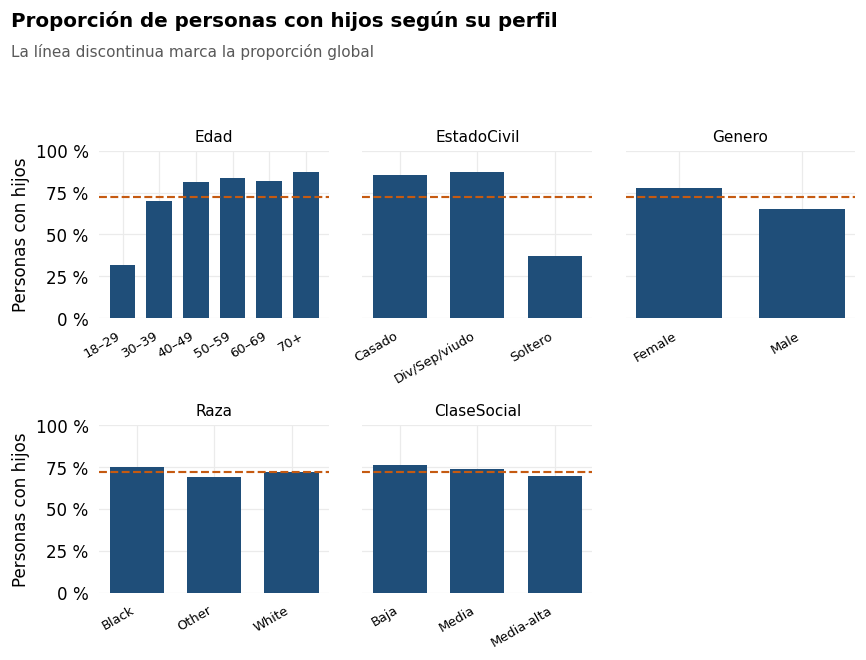

In [7]:
grupos_edad = pd.cut(datos["Edad"], [17, 29, 39, 49, 59, 69, np.inf],
                     labels=["18–29", "30–39", "40–49", "50–59", "60–69", "70+"])
variables_eda = {"Edad": grupos_edad, "EstadoCivil": datos["EstadoCivil"], "Genero": datos["Genero"],
                 "Raza": datos["Raza"], "ClaseSocial": datos["ClaseSocial"]}
tasa_global = np.mean(datos["Hijos"] == "Si")

fig, ejes = plt.subplots(2, 3, figsize=(8, 6), sharey=True)
for ax, (nombre, serie) in zip(ejes.flat, variables_eda.items()):
    prop = (datos["Hijos"] == "Si").groupby(serie.astype(str)).mean().sort_index()
    ax.bar(prop.index, prop.values, color=COL_PRINCIPAL, width=0.7)
    ax.axhline(tasa_global, color=COL_ACENTO, ls="--", lw=1.4)
    ax.set_title(nombre, fontsize=10, fontweight="normal", loc="center")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(lambda v, _: f"{v * 100:.0f} %")
    ax.tick_params(axis="x", rotation=30, labelsize=8.5)
    for etiqueta in ax.get_xticklabels():
        etiqueta.set_ha("right")
ejes.flat[-1].set_visible(False)
ejes[0, 0].set_ylabel("Personas con hijos"); ejes[1, 0].set_ylabel("Personas con hijos")
titulos(fig, "Proporción de personas con hijos según su perfil",
        "La línea discontinua marca la proporción global")
fig.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

La edad y el estado civil muestran las diferencias más marcadas: la proporción de personas con hijos crece
con la edad, y las personas solteras tienen hijos con mucha menor frecuencia que las casadas o las que
alguna vez lo estuvieron. El género y la raza muestran diferencias menores.

## 3. Partición entrenamiento–prueba

Se reserva el 80 % de las observaciones para entrenamiento, estratificando por la variable objetivo. Se usa
la réplica de `caret::createDataPartition()` con el generador de R (`set.seed(12345)`), por lo que la
partición es idéntica a la de la versión en R.

In [8]:
trainIndex = create_data_partition(datos["Hijos"], p=0.8, rng=RRandom(12345))
data_train = datos.iloc[trainIndex - 1].reset_index(drop=True)
data_test = datos.drop(index=datos.index[trainIndex - 1]).reset_index(drop=True)
data_train["y"] = (data_train["Hijos"] == "Si").astype(int)     # respuesta 0/1 para statsmodels
data_test["y"] = (data_test["Hijos"] == "Si").astype(int)

(tabla(pd.DataFrame({"Conjunto": ["Entrenamiento", "Prueba"],
                     "Observaciones": [len(data_train), len(data_test)],
                     "Con hijos": [data_train["y"].mean(), data_test["y"].mean()]}),
       "Resumen de la partición 80/20", "Semilla 12345")
 .fmt_percent(columns="Con hijos", decimals=1))

GT(_tbl_data=        Conjunto  Observaciones  Con hijos
0  Entrenamiento           1629   0.721301
1         Prueba            406   0.721675, _body=<great_tables._gt_data.Body object at 0x7f7b0c81f350>, _boxhead=Boxhead([ColInfo(var='Conjunto', type=<ColInfoTypeEnum.default: 1>, column_label='Conjunto', column_align='left', column_width=None), ColInfo(var='Observaciones', type=<ColInfoTypeEnum.default: 1>, column_label='Observaciones', column_align='right', column_width=None), ColInfo(var='Con hijos', type=<ColInfoTypeEnum.default: 1>, column_label='Con hijos', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f7b0cb70ce0>, _spanners=Spanners([]), _heading=Heading(title='Resumen de la partición 80/20', subtitle='Semilla 12345', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f7b0cb71820>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f7b0c4f3e90>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f7b0c900f50>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f7b0c8d8980>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='13px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#5F5F5F'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#5F5F5F'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='value'

## 4. Selección automática de variables

Se parte de dos modelos de referencia: el modelo nulo (solo intercepto) y el modelo completo (las 12
variables predictoras). Entre ellos, `step_glm()` (réplica de `step()`) busca el mejor subconjunto de
variables con tres estrategias (*stepwise*, *forward* y *backward*) y dos criterios de información:

- **AIC** (criterio de Akaike): penaliza cada parámetro adicional con 2 unidades.
- **BIC** (criterio bayesiano): penaliza cada parámetro con log(n) unidades, lo que favorece modelos más
  simples.

In [9]:
predictores = [c for c in datos.columns if c != "Hijos"]
k_bic = math.log(len(data_train))

terminos = {
    "Stepwise · BIC": step_glm("y", data_train, [], predictores, "both", k_bic),
    "Forward · BIC": step_glm("y", data_train, [], predictores, "forward", k_bic),
    "Backward · BIC": step_glm("y", data_train, predictores, predictores, "backward", k_bic),
    "Stepwise · AIC": step_glm("y", data_train, [], predictores, "both", 2),
    "Forward · AIC": step_glm("y", data_train, [], predictores, "forward", 2),
    "Backward · AIC": step_glm("y", data_train, predictores, predictores, "backward", 2),
}


def ajustar_logistico(terms, datos_ajuste=data_train):
    return smf.glm("y ~ " + " + ".join(terms), data=datos_ajuste, family=sm.families.Binomial()).fit()


def n_parametros(modelo):
    return int(modelo.df_model) + 1


seleccionados = {nombre: ajustar_logistico(t) for nombre, t in terminos.items()}
modeloStepBIC, modeloStepAIC = seleccionados["Stepwise · BIC"], seleccionados["Stepwise · AIC"]
terms_bic, terms_aic = terminos["Stepwise · BIC"], terminos["Stepwise · AIC"]

In [10]:
resumen_seleccion = pd.DataFrame({
    "Método": list(seleccionados),
    "Parámetros": [n_parametros(m) for m in seleccionados.values()],
    "Variables": [", ".join(sorted(t)) for t in terminos.values()],
    "AIC": [m.deviance + 2 * n_parametros(m) for m in seleccionados.values()],
    "BIC": [m.deviance + k_bic * n_parametros(m) for m in seleccionados.values()]})
(tabla(resumen_seleccion, "Modelos obtenidos por selección automática", "Variables en orden alfabético")
 .fmt_number(columns=["AIC", "BIC"], decimals=1))

GT(_tbl_data=           Método  Parámetros  \
0  Stepwise · BIC           9   
1   Forward · BIC           9   
2  Backward · BIC           9   
3  Stepwise · AIC          19   
4   Forward · AIC          19   
5  Backward · AIC          19   

                                           Variables          AIC          BIC  
0       ClaseSocial, Edad, EstadoCivil, Genero, Raza  1436.974778  1485.536272  
1       ClaseSocial, Edad, EstadoCivil, Genero, Raza  1436.974778  1485.536272  
2       ClaseSocial, Edad, EstadoCivil, Genero, Raza  1436.974778  1485.536272  
3  ClaseSocial, Edad, Empleo, EstadoCivil, Genero...  1413.819988  1516.338698  
4  ClaseSocial, Edad, Empleo, EstadoCivil, Genero...  1413.819988  1516.338698  
5  ClaseSocial, Edad, Empleo, EstadoCivil, Genero...  1413.819988  1516.338698  , _body=<great_tables._gt_data.Body object at 0x7f7b0c8c4ec0>, _boxhead=Boxhead([ColInfo(var='Método', type=<ColInfoTypeEnum.default: 1>, column_label='Método', column_align='left', column_width=None), ColInfo(var='Parámetros', type=<ColInfoTypeEnum.default: 1>, column_label='Parámetros', column_align='right', column_width=None), ColInfo(var='Variables', type=<ColInfoTypeEnum.default: 1>, column_label='Variables', column_align='left', column_width=None), ColInfo(var='AIC', type=<ColInfoTypeEnum.default: 1>, column_label='AIC', column_align='right', column_width=None), ColInfo(var='BIC', type=<ColInfoTypeEnum.default: 1>, column_label='BIC', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f7b0c5a31d0>, _spanners=Spanners([]), _heading=Heading(title='Modelos obtenidos por selección automática', subtitle='Variables en orden alfabético', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f7b08b05670>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f7b0c5a12e0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f7b0c5a1280>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f7b0c5a3380>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='13px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#5F5F5F'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_righ

In [11]:
extra_aic = [t for t in terms_aic if t not in terms_bic]
display(Markdown(
    f"Las seis combinaciones producen **solo {resumen_seleccion['Variables'].nunique()} modelos distintos**: "
    "las tres estrategias de búsqueda convergen a la misma solución para cada criterio. Las diferencias se "
    "deben exclusivamente al criterio:\n\n"
    f"- **BIC** selecciona {len(terms_bic)} variables (**{n_parametros(modeloStepBIC)} parámetros**): "
    "estado civil, edad, género, raza y clase social.\n"
    f"- **AIC**, con una penalización menor, incorpora además {', '.join(extra_aic)} "
    f"(**{n_parametros(modeloStepAIC)} parámetros**). Las variables categóricas aportan un parámetro por "
    "cada nivel distinto del de referencia, lo que eleva rápidamente el número total.\n\n"
    "Ninguno de los dos criterios selecciona el **signo del zodiaco**, que funciona como control: una "
    "variable sin relación plausible con la paternidad debe quedar excluida, y así ocurre."))

Las seis combinaciones producen **solo 2 modelos distintos**: las tres estrategias de búsqueda convergen a la misma solución para cada criterio. Las diferencias se deben exclusivamente al criterio:

- **BIC** selecciona 5 variables (**9 parámetros**): estado civil, edad, género, raza y clase social.
- **AIC**, con una penalización menor, incorpora además Empleo, Politica, Region, Tamano (**19 parámetros**). Las variables categóricas aportan un parámetro por cada nivel distinto del de referencia, lo que eleva rápidamente el número total.

Ninguno de los dos criterios selecciona el **signo del zodiaco**, que funciona como control: una variable sin relación plausible con la paternidad debe quedar excluida, y así ocurre.

## 5. Comparación por validación cruzada repetida

Se comparan tres candidatos: el modelo BIC, el modelo AIC y un **modelo de referencia basado en
conocimiento del dominio**, con tres variables (estado civil, edad y raza). Cada modelo se evalúa con
validación cruzada de 5 *folds* repetida 20 veces (100 estimaciones por métrica), usando la misma partición
en todos. Los *folds* replican exactamente los de `caret::train()` tras `set.seed(12345)`, incluida la
semilla interna que `caret` extrae antes de generarlos.

In [12]:
terms_manual = ["EstadoCivil", "Edad", "Raza"]
modeloManual = ajustar_logistico(terms_manual)
candidatos = {f"Referencia ({n_parametros(modeloManual)} parám.)": terms_manual,
              f"BIC ({n_parametros(modeloStepBIC)} parám.)": terms_bic,
              f"AIC ({n_parametros(modeloStepAIC)} parám.)": terms_aic}

folds_vc = caret_repeatedcv_folds(data_train["Hijos"], number=5, repeats=20, seed=12345)
filas = []
for nombre, terms in candidatos.items():
    for i, (idx_ent, idx_val) in enumerate(folds_vc):
        # GlmLogitR reproduce el IRLS de glm() de R (mismo criterio de parada), de modo que las
        # probabilidades coinciden con las de caret hasta la precisión de la máquina
        m = GlmLogitR("y ~ " + " + ".join(terms), data_train.iloc[idx_ent])
        val = data_train.iloc[idx_val]
        prob = m.predict(val)
        obs = val["y"].to_numpy() == 1
        pred = prob >= 0.5                                  # regla de clase de caret para glm
        # multiClassSummary promedia el AUC calculado para cada clase (con p y con 1 − p)
        auc_fold = (auc(obs, prob) + auc(~obs, 1 - prob)) / 2
        filas.append({"Modelo": nombre, "Resample": f"Fold{i % 5 + 1}.Rep{i // 5 + 1:02d}",
                      "AUC": auc_fold, "Kappa": kappa(obs, pred),
                      "Accuracy": np.mean(obs == pred)})
remuestreos = pd.DataFrame(filas)

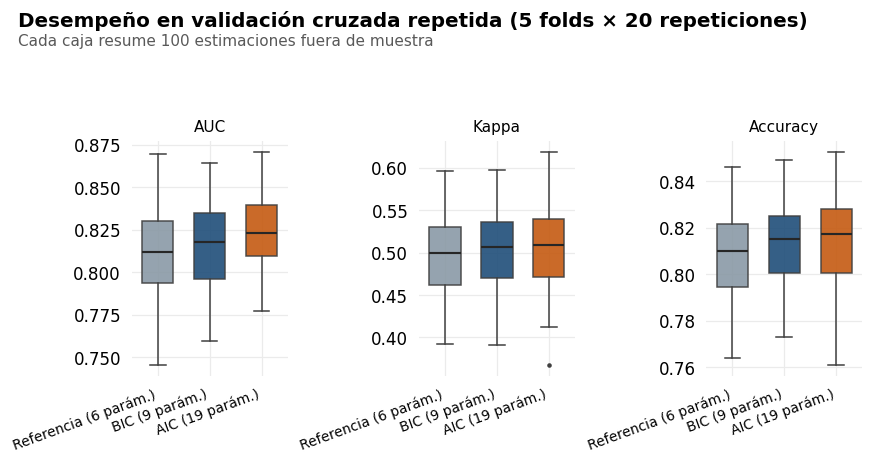

In [13]:
metricas_vc = ["AUC", "Kappa", "Accuracy"]
fig, ejes = plt.subplots(1, 3, figsize=(8, 4.2))
for ax, met in zip(ejes, metricas_vc):
    datos_box = [remuestreos.loc[remuestreos["Modelo"] == m, met] for m in candidatos]
    cajas = ax.boxplot(datos_box, widths=0.6, patch_artist=True,
                       medianprops={"color": "#262626", "lw": 1.4},
                       whiskerprops={"color": "#404040"}, capprops={"color": "#404040"},
                       flierprops={"marker": "o", "markersize": 3, "markerfacecolor": "#404040",
                                   "markeredgecolor": "none"})
    for caja, color in zip(cajas["boxes"], PALETA_MODELOS):
        caja.set(facecolor=color, alpha=0.9, edgecolor="#404040")
    ax.set_xticks(range(1, 4), list(candidatos), rotation=20, ha="right", fontsize=9)
    ax.set_title(met, fontsize=10, fontweight="normal", loc="center")
titulos(fig, "Desempeño en validación cruzada repetida (5 folds × 20 repeticiones)",
        "Cada caja resume 100 estimaciones fuera de muestra")
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

In [14]:
resumen_vc = (remuestreos.melt(id_vars=["Modelo", "Resample"], value_vars=metricas_vc,
                               var_name="Métrica", value_name="Valor")
              .groupby(["Métrica", "Modelo"], sort=False)["Valor"]
              .agg(Media="mean", **{"Desv. est.": "std"}, Mínimo="min", Mediana="median", Máximo="max")
              .reset_index()[["Modelo", "Métrica", "Media", "Desv. est.", "Mínimo", "Mediana", "Máximo"]])
(tabla(resumen_vc, "Resumen de la validación cruzada repetida")
 .fmt_number(columns=["Media", "Desv. est.", "Mínimo", "Mediana", "Máximo"], decimals=4))

GT(_tbl_data=                  Modelo   Métrica     Media  Desv. est.    Mínimo   Mediana  \
0  Referencia (6 parám.)       AUC  0.810454    0.024600  0.745148  0.811745   
1         BIC (9 parám.)       AUC  0.816925    0.024999  0.759341  0.817828   
2        AIC (19 parám.)       AUC  0.823675    0.022046  0.777274  0.822988   
3  Referencia (6 parám.)     Kappa  0.495743    0.044616  0.392060  0.499172   
4         BIC (9 parám.)     Kappa  0.500364    0.046769  0.390839  0.506002   
5        AIC (19 parám.)     Kappa  0.502942    0.046884  0.367116  0.508603   
6  Referencia (6 parám.)  Accuracy  0.808076    0.017176  0.763804  0.809816   
7         BIC (9 parám.)  Accuracy  0.812465    0.017759  0.773006  0.815385   
8        AIC (19 parám.)  Accuracy  0.814460    0.017691  0.760736  0.817485   

     Máximo  
0  0.869628  
1  0.864297  
2  0.870938  
3  0.595476  
4  0.597294  
5  0.618732  
6  0.846154  
7  0.849231  
8  0.852761  , _body=<great_tables._gt_data.Body object at 0x7f7b08b41910>, _boxhead=Boxhead([ColInfo(var='Modelo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='Métrica', type=<ColInfoTypeEnum.default: 1>, column_label='Métrica', column_align='left', column_width=None), ColInfo(var='Media', type=<ColInfoTypeEnum.default: 1>, column_label='Media', column_align='right', column_width=None), ColInfo(var='Desv. est.', type=<ColInfoTypeEnum.default: 1>, column_label='Desv. est.', column_align='right', column_width=None), ColInfo(var='Mínimo', type=<ColInfoTypeEnum.default: 1>, column_label='Mínimo', column_align='right', column_width=None), ColInfo(var='Mediana', type=<ColInfoTypeEnum.default: 1>, column_label='Mediana', column_align='right', column_width=None), ColInfo(var='Máximo', type=<ColInfoTypeEnum.default: 1>, column_label='Máximo', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f7b0c900200>, _spanners=Spanners([]), _heading=Heading(title='Resumen de la validación cruzada repetida', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f7b08a7bfb0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f7b08a79070>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f7b08a780b0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f7b0c509fd0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='13px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=Op

In [15]:
def media_vc(i, met):
    return resumen_vc.query("Modelo == @list(@candidatos)[@i] and Métrica == @met")["Media"].iloc[0]


nombres_c = list(candidatos)
sd_auc_bic = resumen_vc[(resumen_vc["Modelo"] == nombres_c[1]) & (resumen_vc["Métrica"] == "AUC")]["Desv. est."].iloc[0]
m_auc = [resumen_vc[(resumen_vc["Modelo"] == n) & (resumen_vc["Métrica"] == "AUC")]["Media"].iloc[0] for n in nombres_c]
display(Markdown(
    f"El modelo AIC obtiene el mejor AUC medio ({num(m_auc[2], 4)}), seguido del modelo BIC "
    f"({num(m_auc[1], 4)}) y del de referencia ({num(m_auc[0], 4)}). Sin embargo, la ventaja del modelo AIC "
    f"sobre el BIC ({num(m_auc[2] - m_auc[1], 4)}) es muy inferior a la variabilidad entre remuestreos "
    f"(desviación estándar de {num(sd_auc_bic, 4)}), y en Kappa y *accuracy* las diferencias son "
    "prácticamente nulas.\n\nSiguiendo el **principio de parsimonia**, se elige el **modelo BIC**: logra un "
    f"desempeño equivalente con {n_parametros(modeloStepBIC)} parámetros frente a "
    f"{n_parametros(modeloStepAIC)}, lo que lo hace más interpretable y menos propenso al sobreajuste."))

El modelo AIC obtiene el mejor AUC medio (0.8237), seguido del modelo BIC (0.8169) y del de referencia (0.8105). Sin embargo, la ventaja del modelo AIC sobre el BIC (0.0067) es muy inferior a la variabilidad entre remuestreos (desviación estándar de 0.0250), y en Kappa y *accuracy* las diferencias son prácticamente nulas.

Siguiendo el **principio de parsimonia**, se elige el **modelo BIC**: logra un desempeño equivalente con 9 parámetros frente a 19, lo que lo hace más interpretable y menos propenso al sobreajuste.

## 6. Evaluación en el conjunto de prueba

In [16]:
umbral = data_train["y"].mean()

In [17]:
display(Markdown(
    "El umbral de clasificación por defecto (0.5) no es adecuado cuando las clases están desbalanceadas: "
    "clasificaría a casi todas las personas como \"con hijos\". Se usa como umbral la **proporción de "
    f"personas con hijos en entrenamiento** ({num(umbral, 4)}), que equilibra sensibilidad y especificidad."))

El umbral de clasificación por defecto (0.5) no es adecuado cuando las clases están desbalanceadas: clasificaría a casi todas las personas como "con hijos". Se usa como umbral la **proporción de personas con hijos en entrenamiento** (0.7213), que equilibra sensibilidad y especificidad.

In [18]:
probs_test = modeloStepBIC.predict(data_test).to_numpy()
pred_test = np.where(probs_test >= umbral, "Si", "No")
matriz = pd.crosstab(pd.Categorical(pred_test, ["No", "Si"]), data_test["Hijos"], dropna=False)
(tabla(pd.DataFrame({"Predicción": ["No", "Sí"], "Observado: No": matriz["No"].values,
                     "Observado: Sí": matriz["Si"].values}),
       "Matriz de confusión · Modelo BIC en prueba", "Columnas: clase observada"))

GT(_tbl_data=  Predicción  Observado: No  Observado: Sí
0         No             83             50
1         Sí             30            243, _body=<great_tables._gt_data.Body object at 0x7f7b08b4b1d0>, _boxhead=Boxhead([ColInfo(var='Predicción', type=<ColInfoTypeEnum.default: 1>, column_label='Predicción', column_align='left', column_width=None), ColInfo(var='Observado: No', type=<ColInfoTypeEnum.default: 1>, column_label='Observado: No', column_align='right', column_width=None), ColInfo(var='Observado: Sí', type=<ColInfoTypeEnum.default: 1>, column_label='Observado: Sí', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f7b08b48e30>, _spanners=Spanners([]), _heading=Heading(title='Matriz de confusión · Modelo BIC en prueba', subtitle='Columnas: clase observada', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f7b08b496a0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f7b08b49280>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f7b08b4a420>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='13px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#5F5F5F'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#5F5F5F'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_left_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), heading_background_color=OptionsInfo(scss=True, category='heading', type='value', value=None), heading

In [19]:
modelos_candidatos = {"Referencia": modeloManual, "BIC": modeloStepBIC, "AIC": modeloStepAIC}
prob_prueba = {nombre: modelos_candidatos[nombre.split(" (")[0]].predict(data_test).to_numpy()
               for nombre in candidatos}
metricas_prueba = pd.DataFrame([{"Modelo": n, **metricas_clasif(p, data_test["Hijos"], umbral)}
                                for n, p in prob_prueba.items()])
(tabla(metricas_prueba, "Métricas en el conjunto de prueba", f"Umbral de clasificación = {num(umbral, 4)}")
 .fmt_number(columns=list(metricas_prueba.columns[1:]), decimals=4)
 .tab_style(style=style.text(weight="bold"), locations=loc.body(rows=[1])))

GT(_tbl_data=                  Modelo       AUC  Accuracy     Kappa  Sensibilidad  \
0  Referencia (6 parám.)  0.799390  0.798030  0.515668      0.836177   
1         BIC (9 parám.)  0.812951  0.802956  0.534790      0.829352   
2        AIC (19 parám.)  0.815730  0.802956  0.544192      0.815700   

   Especificidad  
0       0.699115  
1       0.734513  
2       0.769912  , _body=<great_tables._gt_data.Body object at 0x7f7b08abb470>, _boxhead=Boxhead([ColInfo(var='Modelo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='AUC', type=<ColInfoTypeEnum.default: 1>, column_label='AUC', column_align='right', column_width=None), ColInfo(var='Accuracy', type=<ColInfoTypeEnum.default: 1>, column_label='Accuracy', column_align='right', column_width=None), ColInfo(var='Kappa', type=<ColInfoTypeEnum.default: 1>, column_label='Kappa', column_align='right', column_width=None), ColInfo(var='Sensibilidad', type=<ColInfoTypeEnum.default: 1>, column_label='Sensibilidad', column_align='right', column_width=None), ColInfo(var='Especificidad', type=<ColInfoTypeEnum.default: 1>, column_label='Especificidad', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f7b08aba210>, _spanners=Spanners([]), _heading=Heading(title='Métricas en el conjunto de prueba', subtitle='Umbral de clasificación = 0.7213', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f7b08abb320>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f7b08aba150>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=None, rows=[1], mask=None), grpname=None, colname='Modelo', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=[1], mask=None), grpname=None, colname='AUC', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=[1], mask=None), grpname=None, colname='Accuracy', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=[1], mask=None), grpname=None, colname='Kappa', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=[1], mask=None), grpname=None, colname='Sensibilidad', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=[1], mask=None), grpname=None, colname='Especificidad', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7f7b08abaf00>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f7b08a2ec30>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='a

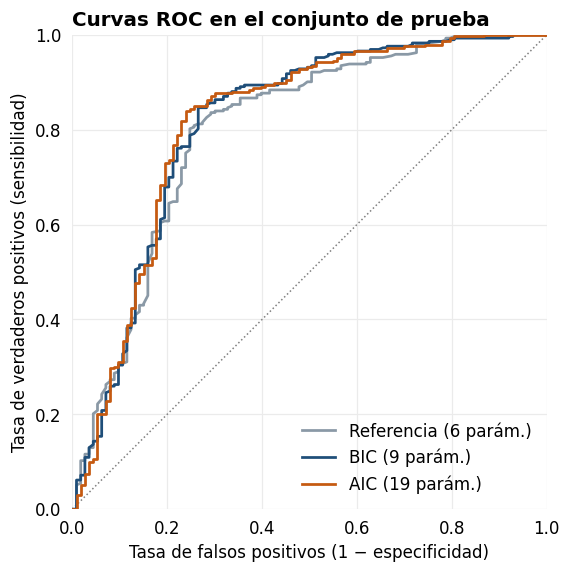

In [20]:
fig, ax = plt.subplots(figsize=(5.6, 5.6))
ax.plot([0, 1], [0, 1], ls=":", color="grey", lw=1)
for (nombre, p), color in zip(prob_prueba.items(), PALETA_MODELOS):
    fpr, tpr = curva_roc(data_test["Hijos"], p)
    ax.plot(fpr, tpr, color=color, lw=1.8, label=nombre)
ax.set_aspect("equal"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc="lower right", frameon=False)
ax.set_title("Curvas ROC en el conjunto de prueba")
ax.set_xlabel("Tasa de falsos positivos (1 − especificidad)")
ax.set_ylabel("Tasa de verdaderos positivos (sensibilidad)")
plt.show()

In [21]:
mp = metricas_prueba.iloc[1]
display(Markdown(
    f"En datos no vistos, el modelo BIC alcanza un **AUC de {num(mp['AUC'])}**. Clasifica correctamente al "
    f"{pct(mp['Accuracy'])} de las personas, con una sensibilidad del {pct(mp['Sensibilidad'])} (personas "
    f"con hijos identificadas) y una especificidad del {pct(mp['Especificidad'])} (personas sin hijos "
    f"identificadas). El índice Kappa de {num(mp['Kappa'])} indica un acuerdo moderado más allá del azar. "
    "Las curvas ROC de los tres modelos son casi indistinguibles, lo que confirma que el estado civil, la "
    "edad y la raza concentran la mayor parte de la información predictiva."))

En datos no vistos, el modelo BIC alcanza un **AUC de 0.813**. Clasifica correctamente al 80.3 % de las personas, con una sensibilidad del 82.9 % (personas con hijos identificadas) y una especificidad del 73.5 % (personas sin hijos identificadas). El índice Kappa de 0.535 indica un acuerdo moderado más allá del azar. Las curvas ROC de los tres modelos son casi indistinguibles, lo que confirma que el estado civil, la edad y la raza concentran la mayor parte de la información predictiva.

## 7. Interpretación del modelo seleccionado

### Importancia de las variables (ANOVA de tipo II)

Para cada variable se compara el modelo BIC con el modelo que la excluye mediante una prueba de razón de
verosimilitudes, que es lo que calcula `car::Anova(type = "II")` para modelos sin interacciones.

In [22]:
filas_anova = []
for t in terms_bic:
    reducido = ajustar_logistico([x for x in terms_bic if x != t])
    lr = reducido.deviance - modeloStepBIC.deviance
    gl = int(modeloStepBIC.df_model - reducido.df_model)
    filas_anova.append({"Variable": t, "Estadístico LR (χ²)": lr, "gl": gl, "p": stats.chi2.sf(lr, gl)})
anova2 = pd.DataFrame(filas_anova).sort_values("Estadístico LR (χ²)", ascending=False)
anova2["p-valor"], anova2["Sig."] = fmt_p(anova2["p"]), estrellas(anova2["p"])
(tabla(anova2.drop(columns="p"), "ANOVA de tipo II · Modelo BIC",
       "Prueba de razón de verosimilitudes por variable")
 .fmt_number(columns="Estadístico LR (χ²)", decimals=2)
 .cols_align("center", columns=["p-valor", "Sig."]))

GT(_tbl_data=      Variable  Estadístico LR (χ²)  gl  p-valor Sig.
0  EstadoCivil           196.845756   2  < 0.001  ***
1         Edad            60.960562   1  < 0.001  ***
2       Genero            26.285361   1  < 0.001  ***
3         Raza            25.693139   2  < 0.001  ***
4  ClaseSocial            18.496407   2  < 0.001  ***, _body=<great_tables._gt_data.Body object at 0x7f7b08bcc2c0>, _boxhead=Boxhead([ColInfo(var='Variable', type=<ColInfoTypeEnum.default: 1>, column_label='Variable', column_align='left', column_width=None), ColInfo(var='Estadístico LR (χ²)', type=<ColInfoTypeEnum.default: 1>, column_label='Estadístico LR (χ²)', column_align='right', column_width=None), ColInfo(var='gl', type=<ColInfoTypeEnum.default: 1>, column_label='gl', column_align='right', column_width=None), ColInfo(var='p-valor', type=<ColInfoTypeEnum.default: 1>, column_label='p-valor', column_align='center', column_width=None), ColInfo(var='Sig.', type=<ColInfoTypeEnum.default: 1>, column_label='Sig.', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f7b0892ffb0>, _spanners=Spanners([]), _heading=Heading(title='ANOVA de tipo II · Modelo BIC', subtitle='Prueba de razón de verosimilitudes por variable', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f7b08ba7650>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f7b08945700>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f7b0892f710>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f7b08965700>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='13px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#5F5F5F'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', val

Las cinco variables son significativas. El **estado civil** es, con gran diferencia, la más importante,
seguido de la edad. Una advertencia metodológica: como las variables se eligieron con los mismos datos,
estos p-valores tienden a ser optimistas. Deben leerse como una medida de importancia relativa, no como
pruebas de hipótesis formales.

### Odds ratios

In [23]:
def nombres_r(modelo, terms, datos_ref=data_train):
    """Coeficientes con nombres y orden de R (p. ej. 'EstadoCivilSoltero')."""
    orden, mapa = ["(Intercept)"], {"Intercept": "(Intercept)"}
    for t in terms:
        if isinstance(datos_ref[t].dtype, pd.CategoricalDtype):
            for nivel in datos_ref[t].cat.categories[1:]:
                mapa[f"{t}[T.{nivel}]"] = f"{t}{nivel}"
                orden.append(f"{t}{nivel}")
        else:
            mapa[t] = t
            orden.append(t)
    return mapa, orden


mapa, orden = nombres_r(modeloStepBIC, terms_bic)
cf = pd.DataFrame({"Coeficiente": modeloStepBIC.params, "Error estándar": modeloStepBIC.bse,
                   "p": modeloStepBIC.pvalues}).rename(index=mapa).loc[orden]
z = stats.norm.ppf(0.975)
odds = pd.DataFrame({
    "Término": cf.index, "Coeficiente": cf["Coeficiente"].values, "Error estándar": cf["Error estándar"].values,
    "Odds ratio": np.exp(cf["Coeficiente"]).values,
    "IC 95 % inf.": np.exp(cf["Coeficiente"] - z * cf["Error estándar"]).values,
    "IC 95 % sup.": np.exp(cf["Coeficiente"] + z * cf["Error estándar"]).values,
    "p-valor": fmt_p(cf["p"]), "Sig.": estrellas(cf["p"])})
(tabla(odds, "Coeficientes y odds ratios · Modelo BIC",
       nota="Intervalos de confianza de Wald al 95 %. Significancia: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1")
 .fmt_number(columns=["Coeficiente", "Error estándar"], decimals=4)
 .fmt_number(columns=["Odds ratio", "IC 95 % inf.", "IC 95 % sup."], decimals=3)
 .cols_align("center", columns=["p-valor", "Sig."]))

GT(_tbl_data=                    Término  Coeficiente  Error estándar  Odds ratio  \
0               (Intercept)     1.582875        0.384767    4.868934   
1  EstadoCivilDiv/Sep/viudo    -0.241711        0.188329    0.785283   
2        EstadoCivilSoltero    -2.169405        0.168259    0.114246   
3                      Edad     0.035147        0.004667    1.035772   
4                GeneroMale    -0.691095        0.135649    0.501027   
5                 RazaOther    -0.857176        0.260122    0.424359   
6                 RazaWhite    -0.926076        0.190429    0.396105   
7          ClaseSocialMedia    -0.018528        0.252499    0.981642   
8     ClaseSocialMedia-alta    -0.608594        0.253686    0.544115   

   IC 95 % inf.  IC 95 % sup.  p-valor Sig.  
0      2.290443     10.350186  < 0.001  ***  
1      0.542900      1.135880   0.1993       
2      0.082152      0.158877  < 0.001  ***  
3      1.026340      1.045290  < 0.001  ***  
4      0.384058      0.653621  < 0.001  ***  
5      0.254869      0.706560  < 0.001  ***  
6      0.272720      0.575313  < 0.001  ***  
7      0.598447      1.610202   0.9415       
8      0.330943      0.894600   0.0164    *  , _body=<great_tables._gt_data.Body object at 0x7f7b08964e00>, _boxhead=Boxhead([ColInfo(var='Término', type=<ColInfoTypeEnum.default: 1>, column_label='Término', column_align='left', column_width=None), ColInfo(var='Coeficiente', type=<ColInfoTypeEnum.default: 1>, column_label='Coeficiente', column_align='right', column_width=None), ColInfo(var='Error estándar', type=<ColInfoTypeEnum.default: 1>, column_label='Error estándar', column_align='right', column_width=None), ColInfo(var='Odds ratio', type=<ColInfoTypeEnum.default: 1>, column_label='Odds ratio', column_align='right', column_width=None), ColInfo(var='IC 95 % inf.', type=<ColInfoTypeEnum.default: 1>, column_label='IC 95 % inf.', column_align='right', column_width=None), ColInfo(var='IC 95 % sup.', type=<ColInfoTypeEnum.default: 1>, column_label='IC 95 % sup.', column_align='right', column_width=None), ColInfo(var='p-valor', type=<ColInfoTypeEnum.default: 1>, column_label='p-valor', column_align='center', column_width=None), ColInfo(var='Sig.', type=<ColInfoTypeEnum.default: 1>, column_label='Sig.', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f7b0c898c80>, _spanners=Spanners([]), _heading=Heading(title='Coeficientes y odds ratios · Modelo BIC', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f7b089650a0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f7b08964890>, _source_notes=['Intervalos de confianza de Wald al 95 %. Significancia: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f7b08964e90>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f7b08965c10>, <great_tables._gt_data.FormatInfo object at 0x7f7b08966900>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif'])

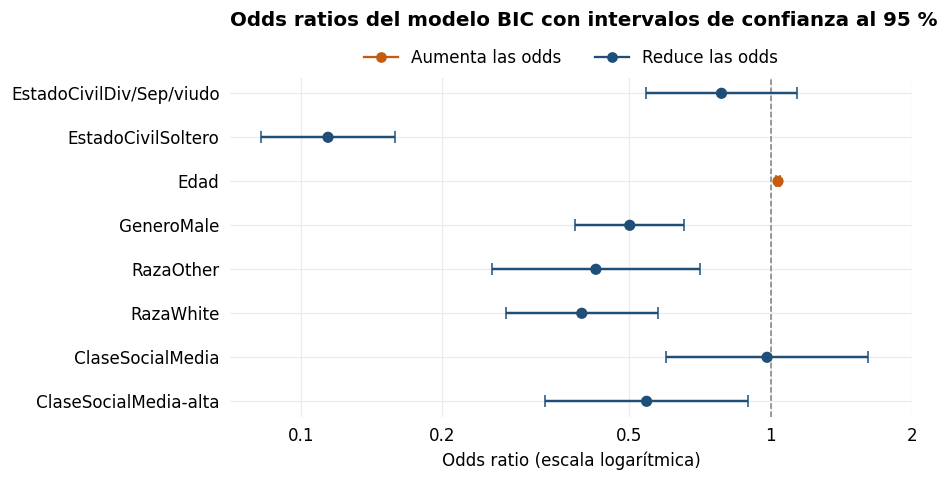

In [24]:
f_or = odds[odds["Término"] != "(Intercept)"].iloc[::-1]
colores = [COL_ACENTO if v > 1 else COL_PRINCIPAL for v in f_or["Odds ratio"]]
fig, ax = plt.subplots(figsize=(8, 4))
ax.axvline(1, ls="--", color="grey", lw=1)
for i, (_, fila) in enumerate(f_or.iterrows()):
    ax.errorbar(fila["Odds ratio"], i,
                xerr=[[fila["Odds ratio"] - fila["IC 95 % inf."]], [fila["IC 95 % sup."] - fila["Odds ratio"]]],
                fmt="none", ecolor=colores[i], elinewidth=1.6, capsize=4)
ax.scatter(f_or["Odds ratio"], range(len(f_or)), color=colores, s=40, zorder=3)
ax.set_xscale("log")
ax.set_xticks([0.1, 0.2, 0.5, 1, 2], ["0.1", "0.2", "0.5", "1", "2"])
ax.minorticks_off()
ax.set_yticks(range(len(f_or)), f_or["Término"])
ax.legend(handles=[Line2D([], [], color=COL_ACENTO, marker="o", label="Aumenta las odds"),
                   Line2D([], [], color=COL_PRINCIPAL, marker="o", label="Reduce las odds")],
          loc="upper center", bbox_to_anchor=(0.5, 1.13), ncol=2, frameon=False)
ax.set_title("Odds ratios del modelo BIC con intervalos de confianza al 95 %", pad=34)
ax.set_xlabel("Odds ratio (escala logarítmica)")
plt.show()

In [25]:
OR = dict(zip(odds["Término"], odds["Odds ratio"]))
p_div = cf.loc["EstadoCivilDiv/Sep/viudo", "p"]
display(Markdown(
    "Un *odds ratio* (OR) compara las *odds* (probabilidad de tener hijos dividida entre la probabilidad de "
    "no tenerlos) de una categoría con las de su categoría de referencia, **manteniendo constantes las demás "
    "variables**:\n\n"
    f"- **Estado civil.** Las *odds* de tener hijos de una persona soltera son {num(OR['EstadoCivilSoltero'])} "
    f"veces las de una persona casada, es decir, un {pct(1 - OR['EstadoCivilSoltero'], 0)} menores. Las "
    "personas divorciadas, separadas o viudas no difieren significativamente de las casadas "
    f"(p = {num(p_div)}), lo que refleja que la mayoría tuvo hijos durante su matrimonio.\n"
    f"- **Edad.** Cada año adicional multiplica las *odds* por {num(OR['Edad'], 4)}, un aumento del "
    f"{pct(OR['Edad'] - 1)} anual. Diez años más de edad equivalen a multiplicar las *odds* por "
    f"{num(OR['Edad'] ** 10, 2)}.\n"
    f"- **Género.** Los hombres declaran tener hijos con *odds* un {pct(1 - OR['GeneroMale'], 0)} menores "
    f"que las mujeres (OR = {num(OR['GeneroMale'])}).\n"
    f"- **Raza.** Frente a las personas de raza negra (referencia), las *odds* son un "
    f"{pct(1 - OR['RazaWhite'], 0)} menores para las personas blancas y un {pct(1 - OR['RazaOther'], 0)} "
    "menores para otras razas.\n"
    "- **Clase social.** Solo la clase media-alta se diferencia significativamente de la clase baja, con "
    f"*odds* un {pct(1 - OR['ClaseSocialMedia-alta'], 0)} menores."))

Un *odds ratio* (OR) compara las *odds* (probabilidad de tener hijos dividida entre la probabilidad de no tenerlos) de una categoría con las de su categoría de referencia, **manteniendo constantes las demás variables**:

- **Estado civil.** Las *odds* de tener hijos de una persona soltera son 0.114 veces las de una persona casada, es decir, un 89 % menores. Las personas divorciadas, separadas o viudas no difieren significativamente de las casadas (p = 0.199), lo que refleja que la mayoría tuvo hijos durante su matrimonio.
- **Edad.** Cada año adicional multiplica las *odds* por 1.0358, un aumento del 3.6 % anual. Diez años más de edad equivalen a multiplicar las *odds* por 1.42.
- **Género.** Los hombres declaran tener hijos con *odds* un 50 % menores que las mujeres (OR = 0.501).
- **Raza.** Frente a las personas de raza negra (referencia), las *odds* son un 60 % menores para las personas blancas y un 58 % menores para otras razas.
- **Clase social.** Solo la clase media-alta se diferencia significativamente de la clase baja, con *odds* un 46 % menores.

## 8. Modelos regularizados

La regularización añade a la función de verosimilitud una penalización sobre el tamaño de los
coeficientes, controlada por el parámetro λ. El parámetro α define el tipo de penalización:

- **Ridge (α = 0):** penalización cuadrática. Reduce los coeficientes hacia cero, pero nunca los anula;
  útil ante predictores correlacionados.
- **LASSO (α = 1):** penalización en valor absoluto. Anula coeficientes y, por tanto, **selecciona
  variables**.
- **Elastic Net (0 < α < 1):** combina ambos efectos.

La clase `Glmnet` del módulo `rcompat` resuelve exactamente el mismo problema de optimización que
`glmnet` de R: estandariza las variables internamente, usa la misma secuencia de λ y las mismas reglas de
parada, y devuelve los coeficientes en la escala original de las variables.

In [26]:
x = model_matrix(data_train.drop(columns="y"), "Hijos")          # model.matrix(Hijos ~ ., data)[, -1]
y = data_train["y"].to_numpy(float)
columnas_x = list(x.columns)

modeloLASSO = Glmnet(alpha=1).fit(x, y)
modeloRIDGE = Glmnet(alpha=0).fit(x, y)
modeloENET = Glmnet(alpha=0.1).fit(x, y)

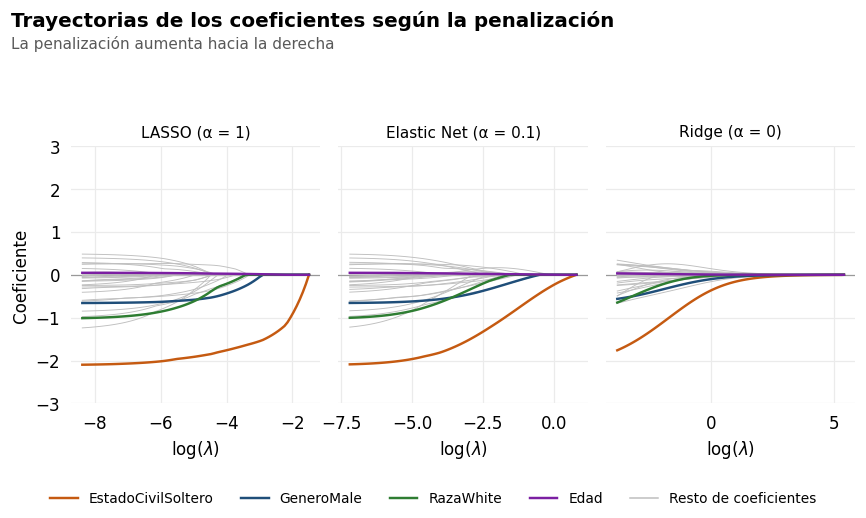

In [27]:
destacados = {"EstadoCivilSoltero": COL_ACENTO, "GeneroMale": COL_PRINCIPAL, "RazaWhite": "#2E7D32",
              "Edad": "#7B1FA2"}
fig, ejes = plt.subplots(1, 3, figsize=(8, 4.6), sharey=True)
for ax, (nombre, m) in zip(ejes, {"LASSO (α = 1)": modeloLASSO, "Elastic Net (α = 0.1)": modeloENET,
                                  "Ridge (α = 0)": modeloRIDGE}.items()):
    ax.axhline(0, color="#999999", lw=0.8)
    loglam = np.log(m.lambdas)
    for j, col in enumerate(columnas_x):
        if col not in destacados:
            ax.plot(loglam, m.beta[j], color="#BFBFBF", lw=0.6)
    for col, color in destacados.items():
        ax.plot(loglam, m.beta[columnas_x.index(col)], color=color, lw=1.6)
    ax.set_ylim(-3, 3)
    ax.set_title(nombre, fontsize=10, fontweight="normal", loc="center")
    ax.set_xlabel(r"$\log(\lambda)$")
ejes[0].set_ylabel("Coeficiente")
fig.legend(handles=[Line2D([], [], color=c, lw=1.6, label=n) for n, c in destacados.items()]
           + [Line2D([], [], color="#BFBFBF", lw=1, label="Resto de coeficientes")],
           loc="lower center", ncol=5, frameon=False, fontsize=9)
titulos(fig, "Trayectorias de los coeficientes según la penalización",
        "La penalización aumenta hacia la derecha")
fig.tight_layout(rect=(0, 0.07, 1, 0.88))
plt.show()

En los tres casos, los coeficientes se contraen hacia cero a medida que aumenta la penalización, pero de
forma distinta:

- **LASSO** anula los coeficientes de uno en uno. La mayoría desaparece pronto, y las últimas en salir son
  las más informativas (ser soltero, la edad y el género), lo que coincide con el análisis anterior.
- **Ridge** reduce todos los coeficientes de forma gradual y simultánea, sin anular ninguno. Por eso
  conserva siempre todos los parámetros.
- **Elastic Net** con α = 0.1 muestra un comportamiento intermedio.

El coeficiente de la edad parece pequeño porque está expresado por año; su importancia es comparable a la
de las variables categóricas una vez escalado.

## 9. Ajuste de hiperparámetros por validación cruzada

El valor de λ se elige por validación cruzada de 5 *folds*, maximizando el AUC. Para que la comparación
entre distintos valores de α sea justa, **todos los modelos se evalúan con la misma asignación de
observaciones a los folds**, generada con el generador de R (`set.seed(12345)`).

In [28]:
foldid = np.array(RRandom(12345).sample([(i % 5) + 1 for i in range(len(y))]))   # sample(rep(1:5, ...))
pd.Series(foldid).value_counts().sort_index()

1    326
2    326
3    326
4    326
5    325
Name: count, dtype: int64

### LASSO: elección de λ

In [29]:
cv_lasso = CVGlmnet(alpha=1, foldid=foldid).fit(x, y)
idx = [cv_lasso.index_min, cv_lasso.index_1se]
(tabla(pd.DataFrame({"Criterio": ["λ mínimo (máximo AUC)", "λ 1-SE (regla de un error estándar)"],
                     "Lambda": cv_lasso.lambdas[idx], "Parámetros no nulos": cv_lasso.nzero[idx],
                     "AUC medio": cv_lasso.cvm[idx], "Error estándar": cv_lasso.cvsd[idx]}),
       "LASSO · λ seleccionados por validación cruzada")
 .fmt_number(columns=["Lambda", "AUC medio", "Error estándar"], decimals=4))

GT(_tbl_data=                              Criterio    Lambda  Parámetros no nulos  \
0                λ mínimo (máximo AUC)  0.001942                   28   
1  λ 1-SE (regla de un error estándar)  0.096644                    2   

   AUC medio  Error estándar  
0   0.818483        0.009200  
1   0.809893        0.009709  , _body=<great_tables._gt_data.Body object at 0x7f7b0c5a0920>, _boxhead=Boxhead([ColInfo(var='Criterio', type=<ColInfoTypeEnum.default: 1>, column_label='Criterio', column_align='left', column_width=None), ColInfo(var='Lambda', type=<ColInfoTypeEnum.default: 1>, column_label='Lambda', column_align='right', column_width=None), ColInfo(var='Parámetros no nulos', type=<ColInfoTypeEnum.default: 1>, column_label='Parámetros no nulos', column_align='right', column_width=None), ColInfo(var='AUC medio', type=<ColInfoTypeEnum.default: 1>, column_label='AUC medio', column_align='right', column_width=None), ColInfo(var='Error estándar', type=<ColInfoTypeEnum.default: 1>, column_label='Error estándar', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f7b088bac90>, _spanners=Spanners([]), _heading=Heading(title='LASSO · λ seleccionados por validación cruzada', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f7b087726f0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f7b088200b0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f7b08820170>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f7b08b329c0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='13px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#5F5F5F'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px')

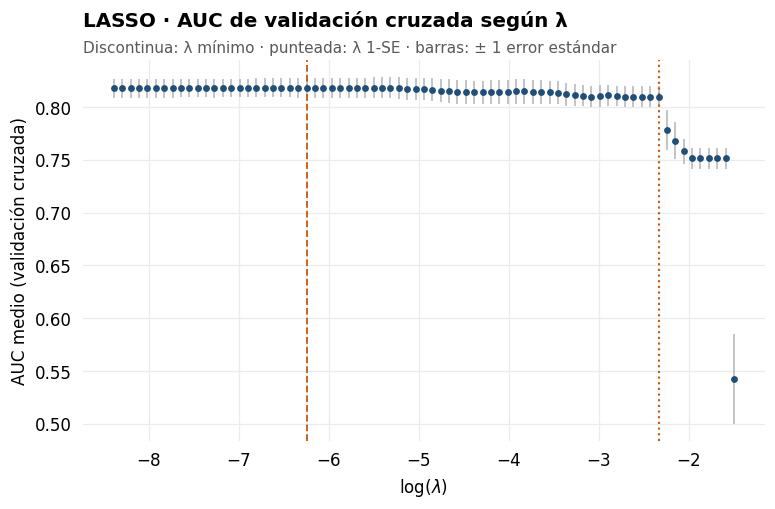

In [30]:
fig, ax = plt.subplots()
loglam = np.log(cv_lasso.lambdas)
ax.errorbar(loglam, cv_lasso.cvm, yerr=cv_lasso.cvsd, fmt="none", ecolor="#B3B3B3", elinewidth=1)
ax.scatter(loglam, cv_lasso.cvm, color=COL_PRINCIPAL, s=12, zorder=3)
ax.axvline(np.log(cv_lasso.lambda_min), color=COL_ACENTO, ls="--", lw=1.2)
ax.axvline(np.log(cv_lasso.lambda_1se), color=COL_ACENTO, ls=":", lw=1.4)
titulos(ax, "LASSO · AUC de validación cruzada según λ",
        "Discontinua: λ mínimo · punteada: λ 1-SE · barras: ± 1 error estándar")
ax.set_xlabel(r"$\log(\lambda)$"); ax.set_ylabel("AUC medio (validación cruzada)")
plt.show()

In [31]:
display(Markdown(
    "El AUC se mantiene prácticamente constante en un amplio rango de λ y solo cae con las penalizaciones "
    "más fuertes. La **regla de un error estándar (1-SE)** elige el λ más grande (el modelo más simple) cuyo "
    "AUC está a menos de un error estándar del máximo. Aquí reduce los parámetros no nulos de "
    f"{cv_lasso.nzero[idx[0]]} a {cv_lasso.nzero[idx[1]]}, con una pérdida de AUC de solo "
    f"{num(cv_lasso.cvm[idx[0]] - cv_lasso.cvm[idx[1]], 4)}."))

El AUC se mantiene prácticamente constante en un amplio rango de λ y solo cae con las penalizaciones más fuertes. La **regla de un error estándar (1-SE)** elige el λ más grande (el modelo más simple) cuyo AUC está a menos de un error estándar del máximo. Aquí reduce los parámetros no nulos de 28 a 2, con una pérdida de AUC de solo 0.0086.

### Búsqueda conjunta de α y λ

In [32]:
alphas = np.round(np.arange(0, 1.0001, 0.1), 1)
tunningEnet = [CVGlmnet(alpha=a, foldid=foldid).fit(x, y) for a in alphas]

resultado = pd.concat([pd.DataFrame({
    "alpha": a, "lambda": cv.lambdas, "numPar": cv.nzero, "auc_cv": cv.cvm, "auc_lo": cv.cvlo,
    "posicion": np.arange(1, len(cv.lambdas) + 1)}) for a, cv in zip(alphas, tunningEnet)],
    ignore_index=True)

# Umbral de la regla 1-SE a partir del mejor modelo global
auc_1se = resultado.loc[resultado["auc_cv"].idxmax(), "auc_lo"]

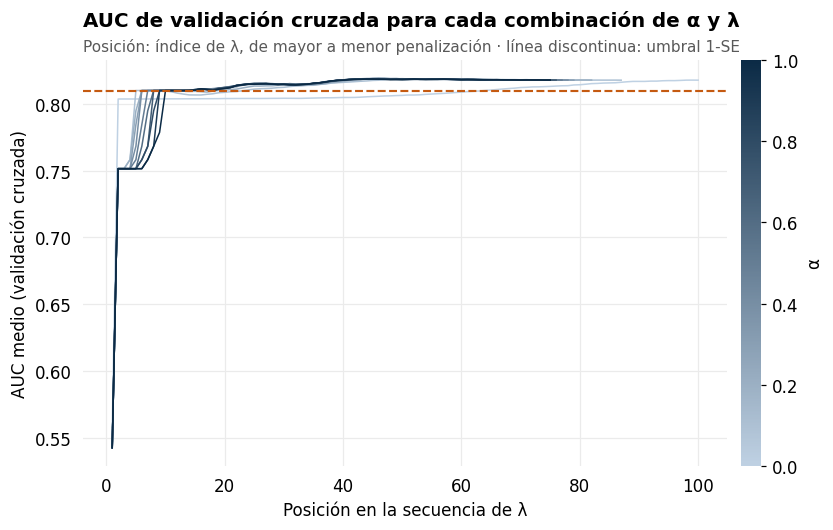

In [33]:
fig, ax = plt.subplots(figsize=(8, 4.8))
cmap = mcolors.LinearSegmentedColormap.from_list("alpha", ["#BFD1E3", "#0B2A45"])
for a in alphas:
    sub = resultado[resultado["alpha"] == a]
    ax.plot(sub["posicion"], sub["auc_cv"], color=cmap(a), lw=1)
ax.axhline(auc_1se, color=COL_ACENTO, ls="--", lw=1.4)
barra = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(0, 1)), ax=ax,
                     fraction=0.035, pad=0.02)
barra.set_label("α"); barra.outline.set_visible(False)
titulos(ax, "AUC de validación cruzada para cada combinación de α y λ",
        "Posición: índice de λ, de mayor a menor penalización · línea discontinua: umbral 1-SE")
ax.set_xlabel("Posición en la secuencia de λ"); ax.set_ylabel("AUC medio (validación cruzada)")
plt.show()

In [34]:
display(Markdown(
    "La línea discontinua marca el **umbral de la regla 1-SE**: el AUC del mejor modelo menos su error "
    f"estándar ({num(auc_1se, 4)}). Cualquier combinación por encima de ella tiene un desempeño "
    "estadísticamente equivalente al óptimo. Salvo Ridge (α = 0) y las penalizaciones más fuertes, casi todas "
    "las combinaciones superan el umbral, así que se elige la que **use menos parámetros**. La comparación "
    "se hace con cuatro decimales, porque diferencias de AUC menores a 0.0001 carecen de relevancia práctica "
    "y no deben decidir la selección. En caso de empate, se prefiere el mayor α (más selección de variables) "
    "y el mayor λ (más penalización)."))

La línea discontinua marca el **umbral de la regla 1-SE**: el AUC del mejor modelo menos su error estándar (0.8099). Cualquier combinación por encima de ella tiene un desempeño estadísticamente equivalente al óptimo. Salvo Ridge (α = 0) y las penalizaciones más fuertes, casi todas las combinaciones superan el umbral, así que se elige la que **use menos parámetros**. La comparación se hace con cuatro decimales, porque diferencias de AUC menores a 0.0001 carecen de relevancia práctica y no deben decidir la selección. En caso de empate, se prefiere el mayor α (más selección de variables) y el mayor λ (más penalización).

In [35]:
# Se compara con 4 decimales: diferencias de AUC menores a 0.0001 no son relevantes
sobre_umbral = resultado[resultado["auc_cv"].round(4) >= round(auc_1se, 4)]
candidatos_1se = (sobre_umbral[sobre_umbral["numPar"] == sobre_umbral["numPar"].min()]
                  .sort_values(["alpha", "lambda"], ascending=False).reset_index(drop=True))
(tabla(candidatos_1se.head(8), "Combinaciones con el menor número de parámetros sobre el umbral 1-SE",
       "Se muestran las 8 primeras; la primera fila es la seleccionada")
 .fmt_number(columns=["lambda", "auc_cv", "auc_lo"], decimals=4)
 .cols_label(alpha="α", **{"lambda": "λ"}, numPar="Parámetros no nulos", auc_cv="AUC medio",
             auc_lo="AUC − 1 EE", posicion="Posición")
 .tab_style(style=style.text(weight="bold"), locations=loc.body(rows=[0])))

GT(_tbl_data=   alpha    lambda  numPar    auc_cv    auc_lo  posicion
0    1.0  0.096644       2  0.809893  0.800183        10
1    1.0  0.088058       2  0.809893  0.800183        11
2    1.0  0.080235       2  0.809893  0.800183        12
3    1.0  0.073107       2  0.809893  0.800183        13
4    1.0  0.066613       2  0.809893  0.800183        14
5    1.0  0.060695       2  0.810221  0.800634        15
6    1.0  0.055303       2  0.811059  0.801238        16
7    0.9  0.117851       2  0.809893  0.800183         9, _body=<great_tables._gt_data.Body object at 0x7f7b08944d70>, _boxhead=Boxhead([ColInfo(var='alpha', type=<ColInfoTypeEnum.default: 1>, column_label='α', column_align='right', column_width=None), ColInfo(var='lambda', type=<ColInfoTypeEnum.default: 1>, column_label='λ', column_align='right', column_width=None), ColInfo(var='numPar', type=<ColInfoTypeEnum.default: 1>, column_label='Parámetros no nulos', column_align='right', column_width=None), ColInfo(var='auc_cv', type=<ColInfoTypeEnum.default: 1>, column_label='AUC medio', column_align='right', column_width=None), ColInfo(var='auc_lo', type=<ColInfoTypeEnum.default: 1>, column_label='AUC − 1 EE', column_align='right', column_width=None), ColInfo(var='posicion', type=<ColInfoTypeEnum.default: 1>, column_label='Posición', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f7b08b05b20>, _spanners=Spanners([]), _heading=Heading(title='Combinaciones con el menor número de parámetros sobre el umbral 1-SE', subtitle='Se muestran las 8 primeras; la primera fila es la seleccionada', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f7b08965190>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f7b08945d00>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=None, rows=[0], mask=None), grpname=None, colname='alpha', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=[0], mask=None), grpname=None, colname='lambda', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=[0], mask=None), grpname=None, colname='numPar', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=[0], mask=None), grpname=None, colname='auc_cv', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=[0], mask=None), grpname=None, colname='auc_lo', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns=None, rows=[0], mask=None), grpname=None, colname='posicion', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7f7b08aba8d0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f7b0c585430>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='t

### Modelo regularizado definitivo

In [36]:
alpha_opt = candidatos_1se.loc[0, "alpha"]
lambda_opt = candidatos_1se.loc[0, "lambda"]
modeloEnetDef = tunningEnet[int(np.where(alphas == alpha_opt)[0][0])].glmnet_fit
a0_def, beta_def = modeloEnetDef.coef_s(lambda_opt)
coef_def = pd.Series(np.concatenate([a0_def, beta_def[:, 0]]), index=["(Intercept)"] + columnas_x)

no_nulos = coef_def[coef_def != 0]
(tabla(pd.DataFrame({"Término": no_nulos.index, "Coeficiente": no_nulos.values,
                     "Odds ratio": np.exp(no_nulos.values)}),
       f"Coeficientes no nulos del modelo regularizado (α = {alpha_opt:g}, λ = {num(lambda_opt, 4)})",
       nota="Coeficientes en la escala original de las variables, contraídos por la penalización.")
 .fmt_number(columns=["Coeficiente", "Odds ratio"], decimals=4))

GT(_tbl_data=              Término  Coeficiente  Odds ratio
0         (Intercept)     1.240239    3.456439
1                Edad     0.002879    1.002884
2  EstadoCivilSoltero    -1.253344    0.285548, _body=<great_tables._gt_data.Body object at 0x7f7b086fad80>, _boxhead=Boxhead([ColInfo(var='Término', type=<ColInfoTypeEnum.default: 1>, column_label='Término', column_align='left', column_width=None), ColInfo(var='Coeficiente', type=<ColInfoTypeEnum.default: 1>, column_label='Coeficiente', column_align='right', column_width=None), ColInfo(var='Odds ratio', type=<ColInfoTypeEnum.default: 1>, column_label='Odds ratio', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f7b085120f0>, _spanners=Spanners([]), _heading=Heading(title='Coeficientes no nulos del modelo regularizado (α = 1, λ = 0.0966)', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f7b0892e180>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f7b0c4d5fd0>, _source_notes=['Coeficientes en la escala original de las variables, contraídos por la penalización.'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f7b0c4d7dd0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f7b08529a90>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='13px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#5F5F5F'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_bottom_color=OptionsInfo(scss=True, category='table', type='value', value='#5F5F5F'), table_border_left_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_left_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_borde

In [37]:
display(Markdown(
    f"El modelo definitivo, con **α = {alpha_opt:g}** y **λ = {num(lambda_opt, 4)}**, conserva solo "
    f"{int((coef_def.iloc[1:] != 0).sum())} variables con coeficiente no nulo: ser soltero y la edad. "
    "Coincide con el λ 1-SE del LASSO de la sección anterior. Los signos concuerdan con los del modelo "
    "logístico: ser soltero reduce la probabilidad de tener hijos y la edad la aumenta. Sus magnitudes son "
    "menores porque la penalización las contrae hacia cero. Este sesgo deliberado reduce la varianza del "
    "modelo, pero implica que los *odds ratios* no deben interpretarse con la misma literalidad que en el "
    "modelo sin penalizar."))

El modelo definitivo, con **α = 1** y **λ = 0.0966**, conserva solo 2 variables con coeficiente no nulo: ser soltero y la edad. Coincide con el λ 1-SE del LASSO de la sección anterior. Los signos concuerdan con los del modelo logístico: ser soltero reduce la probabilidad de tener hijos y la edad la aumenta. Sus magnitudes son menores porque la penalización las contrae hacia cero. Este sesgo deliberado reduce la varianza del modelo, pero implica que los *odds ratios* no deben interpretarse con la misma literalidad que en el modelo sin penalizar.

## 10. Evaluación del modelo regularizado en prueba

In [38]:
x_test = model_matrix(data_test.drop(columns="y"), "Hijos")
probs_test_enet = modeloEnetDef.predict_proba_s(x_test, lambda_opt)[:, 0]
n_par_enet = int((coef_def != 0).sum())

comparacion_final = pd.DataFrame([
    {"Modelo": f"Logístico BIC ({n_parametros(modeloStepBIC)} parámetros)",
     **metricas_clasif(probs_test, data_test["Hijos"], umbral)},
    {"Modelo": f"Regularizado, α = {alpha_opt:g} ({n_par_enet} parámetros)",
     **metricas_clasif(probs_test_enet, data_test["Hijos"], umbral)}])
(tabla(comparacion_final, "Modelo logístico vs. modelo regularizado en prueba",
       f"Umbral de clasificación = {num(umbral, 4)}")
 .fmt_number(columns=list(comparacion_final.columns[1:]), decimals=4))

GT(_tbl_data=                               Modelo       AUC  Accuracy     Kappa  \
0        Logístico BIC (9 parámetros)  0.812951  0.802956  0.534790   
1  Regularizado, α = 1 (3 parámetros)  0.789060  0.795567  0.503258   

   Sensibilidad  Especificidad  
0      0.829352       0.734513  
1      0.843003       0.672566  , _body=<great_tables._gt_data.Body object at 0x7f7b0852aa50>, _boxhead=Boxhead([ColInfo(var='Modelo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='AUC', type=<ColInfoTypeEnum.default: 1>, column_label='AUC', column_align='right', column_width=None), ColInfo(var='Accuracy', type=<ColInfoTypeEnum.default: 1>, column_label='Accuracy', column_align='right', column_width=None), ColInfo(var='Kappa', type=<ColInfoTypeEnum.default: 1>, column_label='Kappa', column_align='right', column_width=None), ColInfo(var='Sensibilidad', type=<ColInfoTypeEnum.default: 1>, column_label='Sensibilidad', column_align='right', column_width=None), ColInfo(var='Especificidad', type=<ColInfoTypeEnum.default: 1>, column_label='Especificidad', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f7b0852ab70>, _spanners=Spanners([]), _heading=Heading(title='Modelo logístico vs. modelo regularizado en prueba', subtitle='Umbral de clasificación = 0.7213', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f7b0852a9c0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f7b085281d0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f7b0852a810>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7f7b0852b620>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='13px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#5F5F5F'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='ta

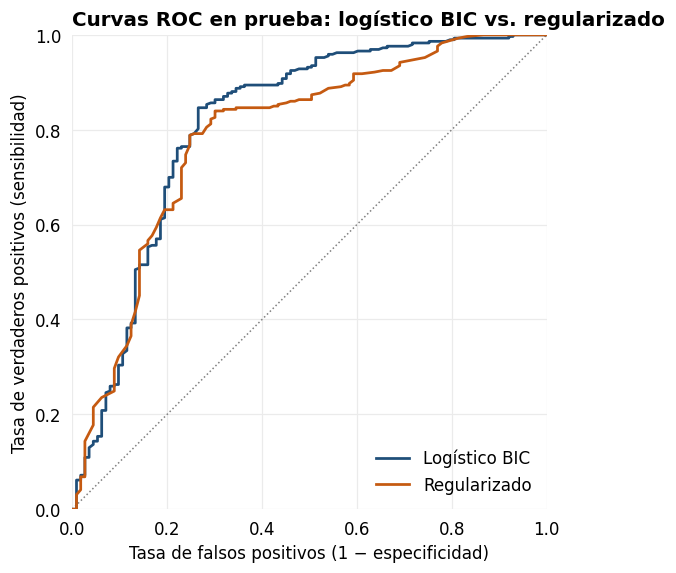

In [39]:
fig, ax = plt.subplots(figsize=(5.6, 5.6))
ax.plot([0, 1], [0, 1], ls=":", color="grey", lw=1)
for (nombre, p), color in zip({"Logístico BIC": probs_test, "Regularizado": probs_test_enet}.items(),
                              [COL_PRINCIPAL, COL_ACENTO]):
    fpr, tpr = curva_roc(data_test["Hijos"], p)
    ax.plot(fpr, tpr, color=color, lw=1.8, label=nombre)
ax.set_aspect("equal"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc="lower right", frameon=False)
ax.set_title("Curvas ROC en prueba: logístico BIC vs. regularizado")
ax.set_xlabel("Tasa de falsos positivos (1 − especificidad)")
ax.set_ylabel("Tasa de verdaderos positivos (sensibilidad)")
plt.show()

In [40]:
display(Markdown(
    f"Con solo dos variables, el modelo regularizado obtiene un AUC de {num(comparacion_final.loc[1, 'AUC'])} "
    f"frente a {num(comparacion_final.loc[0, 'AUC'])} del modelo BIC. Cede algo de capacidad discriminante a "
    f"cambio de una simplicidad considerable: {n_par_enet} parámetros frente a {n_parametros(modeloStepBIC)}, "
    "y sin necesidad de recoger género, raza ni clase social."))

Con solo dos variables, el modelo regularizado obtiene un AUC de 0.789 frente a 0.813 del modelo BIC. Cede algo de capacidad discriminante a cambio de una simplicidad considerable: 3 parámetros frente a 9, y sin necesidad de recoger género, raza ni clase social.

## 11. Conclusiones

In [41]:
display(Markdown(
    "- **Qué determina la paternidad.** El estado civil es el factor dominante: las *odds* de tener hijos de "
    f"una persona soltera son un {pct(1 - OR['EstadoCivilSoltero'], 0)} menores que las de una casada. Le "
    "siguen la edad, el género, la raza y la clase social. Las variables de actitud (felicidad, política), "
    "la región y el signo del zodiaco no aportan información.\n"
    f"- **Modelo recomendado.** El modelo logístico seleccionado por BIC ({n_parametros(modeloStepBIC)} "
    "parámetros) ofrece el mejor equilibrio entre precisión e interpretabilidad: AUC de "
    f"{num(mp['AUC'])} en prueba, sensibilidad del {pct(mp['Sensibilidad'])} y especificidad del "
    f"{pct(mp['Especificidad'])}.\n"
    "- **Alternativa mínima.** Si se requiere un modelo con la menor cantidad de información posible, el "
    "modelo regularizado con solo dos variables (estado civil y edad) mantiene un AUC de "
    f"{num(comparacion_final.loc[1, 'AUC'])}.\n"
    "- **Solidez del proceso.** La selección de variables es estable (las tres estrategias coinciden), el "
    "control negativo (zodiaco) queda excluido y las métricas de validación cruzada y de prueba son "
    "coherentes entre sí.\n\n"
    "**Próximos pasos:** explorar interacciones (por ejemplo, edad × estado civil) y efectos no lineales de "
    "la edad mediante *splines*; calibrar las probabilidades estimadas; y elegir el umbral de clasificación "
    "según el coste relativo de los falsos positivos y negativos en la aplicación concreta."))

- **Qué determina la paternidad.** El estado civil es el factor dominante: las *odds* de tener hijos de una persona soltera son un 89 % menores que las de una casada. Le siguen la edad, el género, la raza y la clase social. Las variables de actitud (felicidad, política), la región y el signo del zodiaco no aportan información.
- **Modelo recomendado.** El modelo logístico seleccionado por BIC (9 parámetros) ofrece el mejor equilibrio entre precisión e interpretabilidad: AUC de 0.813 en prueba, sensibilidad del 82.9 % y especificidad del 73.5 %.
- **Alternativa mínima.** Si se requiere un modelo con la menor cantidad de información posible, el modelo regularizado con solo dos variables (estado civil y edad) mantiene un AUC de 0.789.
- **Solidez del proceso.** La selección de variables es estable (las tres estrategias coinciden), el control negativo (zodiaco) queda excluido y las métricas de validación cruzada y de prueba son coherentes entre sí.

**Próximos pasos:** explorar interacciones (por ejemplo, edad × estado civil) y efectos no lineales de la edad mediante *splines*; calibrar las probabilidades estimadas; y elegir el umbral de clasificación según el coste relativo de los falsos positivos y negativos en la aplicación concreta.

## Anexo: entorno de ejecución

In [42]:
import sys, platform, matplotlib, scipy, statsmodels, great_tables
print("Python", sys.version.split()[0], "·", platform.platform())
for mod in (np, pd, statsmodels, scipy, matplotlib, pyreadr, great_tables):
    print(f"{mod.__name__:>14}: {mod.__version__}")

Python 3.12.3 · Linux-6.18.44-fc-v42-x86_64-with-glibc2.39
         numpy: 2.4.4
        pandas: 3.0.2
   statsmodels: 0.15.0
         scipy: 1.17.1
    matplotlib: 3.10.8
       pyreadr: 0.5.6
  great_tables: 1.0.0
